# UWB Distance Estimation (Regression)

This notebook trains regression estimators to predict the True `RANGE` variable from a processed set of UWB signal features.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load Regression Data generated from preprocessing pipeline
data = np.load('regression_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (33600, 104)
y_train shape: (33600,)
X_test shape: (8400, 104)
y_test shape: (8400,)


## 1. Random Forest Regressor
A strong baseline ensemble learning method.

In [2]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R2:   {rf_r2:.4f}")

Random Forest Performance:
RMSE: 1.1496
MAE:  0.8534
R2:   0.7596


## 2. HistGradientBoosting Regressor
A faster, highly performant gradient boosting implementation optimized for large tabular datasets.

In [3]:
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=10, random_state=42)
hgb.fit(X_train, y_train)

hgb_preds = hgb.predict(X_test)

hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_preds))
hgb_mae = mean_absolute_error(y_test, hgb_preds)
hgb_r2 = r2_score(y_test, hgb_preds)

print("HistGradientBoosting Performance:")
print(f"RMSE: {hgb_rmse:.4f}")
print(f"MAE:  {hgb_mae:.4f}")
print(f"R2:   {hgb_r2:.4f}")

HistGradientBoosting Performance:
RMSE: 1.1392
MAE:  0.8577
R2:   0.7639


## Visualization: True vs Predicted Distances

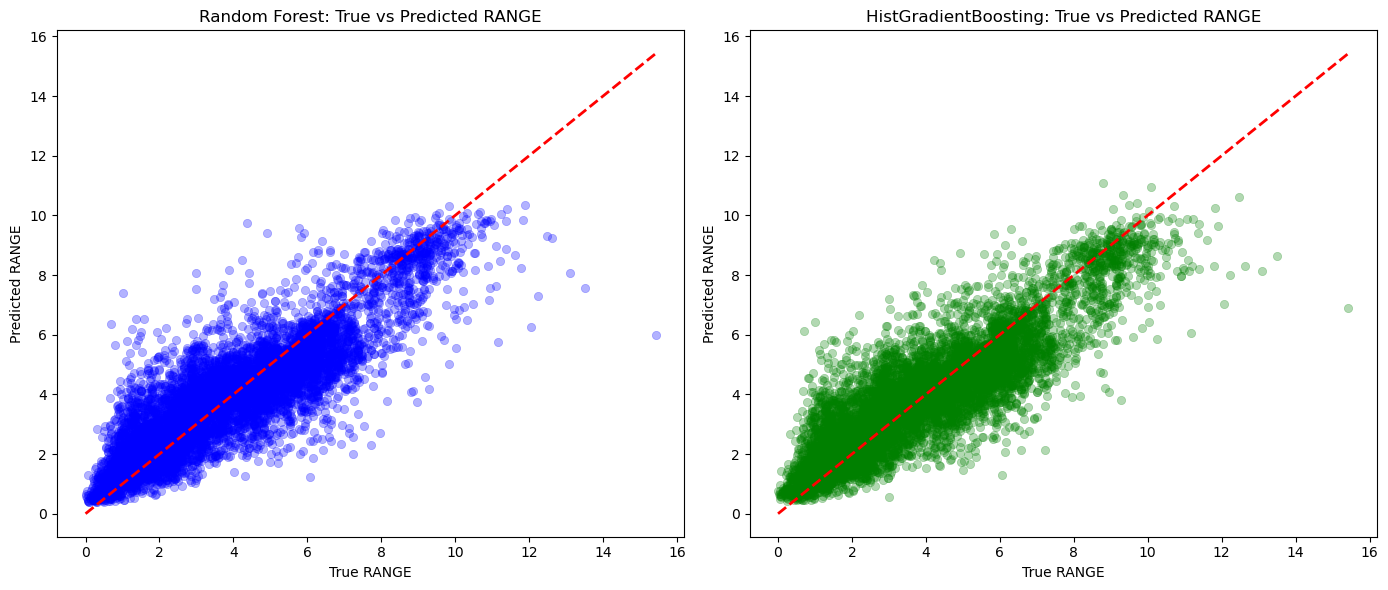

In [4]:
plt.figure(figsize=(14, 6))

# Random Forest Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.3, color='blue', edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: True vs Predicted RANGE')
plt.xlabel('True RANGE')
plt.ylabel('Predicted RANGE')

# HistGradientBoosting Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=hgb_preds, alpha=0.3, color='green', edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('HistGradientBoosting: True vs Predicted RANGE')
plt.xlabel('True RANGE')
plt.ylabel('Predicted RANGE')

plt.tight_layout()
plt.show()

## Visualization: Residual Plots
A residual plot evaluates the variance of the errors. Ideal residual plots have no distinct patterns and are centered tightly around 0.

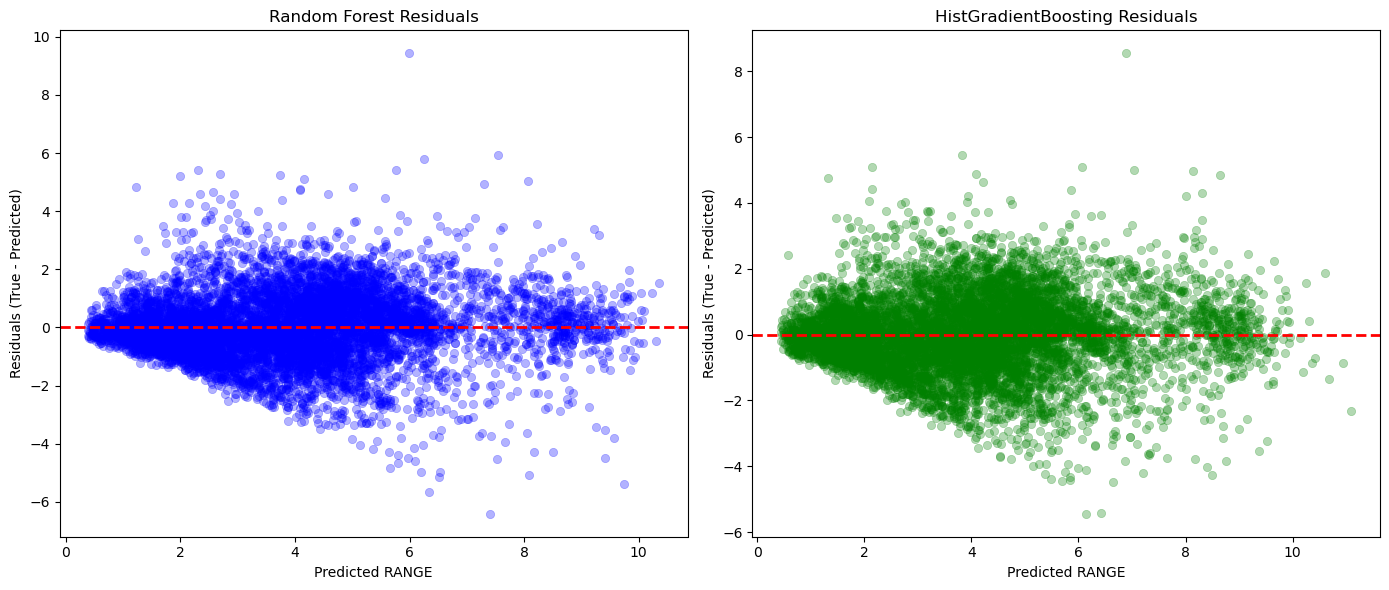

In [5]:
plt.figure(figsize=(14, 6))

rf_residuals = y_test - rf_preds
hgb_residuals = y_test - hgb_preds

# Random Forest Residuals
plt.subplot(1, 2, 1)
sns.scatterplot(x=rf_preds, y=rf_residuals, alpha=0.3, color='blue', edgecolor=None)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Random Forest Residuals')
plt.xlabel('Predicted RANGE')
plt.ylabel('Residuals (True - Predicted)')

# HistGradientBoosting Residuals
plt.subplot(1, 2, 2)
sns.scatterplot(x=hgb_preds, y=hgb_residuals, alpha=0.3, color='green', edgecolor=None)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('HistGradientBoosting Residuals')
plt.xlabel('Predicted RANGE')
plt.ylabel('Residuals (True - Predicted)')

plt.tight_layout()
plt.show()